In [1]:
import os
import random
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

In [38]:
# 数据集根目录
ROOT_DIR = '/data/Mucus_data'

# 获取所有病人目录
patient_dirs = []
for patient_id in os.listdir(ROOT_DIR):
    patient_dir = os.path.join(ROOT_DIR, patient_id)
    if os.path.isdir(patient_dir):
        # 检查必要文件是否存在
        image_path = os.path.join(patient_dir, 'image.nii.gz')
        combined_mask_path = os.path.join(patient_dir, 'combined_mask.nii.gz')
        if os.path.exists(image_path) and os.path.exists(combined_mask_path):
            patient_dirs.append(patient_dir)

if not patient_dirs:
    print("No valid patient directories found!")
    exit(1)
len(patient_dirs)

179

In [94]:
patient_idx = 12
selected_patient_dir = patient_dirs[patient_idx]
patient_id = os.path.basename(selected_patient_dir)
print(f"Selected patient: {patient_id}")
# 加载文件
image_path = os.path.join(selected_patient_dir, 'image.nii.gz')
combined_mask_path = os.path.join(selected_patient_dir, 'combined_mask.nii.gz')

image_img = nib.load(image_path)
image_data = image_img.get_fdata()

combined_mask_img = nib.load(combined_mask_path)
combined_mask_data = combined_mask_img.get_fdata()
combined_mask_data.shape
for z in range(combined_mask_data.shape[1]):
    if 2 in np.unique(combined_mask_data[:, :, z]):
        print(z)

Selected patient: E0001031_20091224
67
68
69
211
212
213
328
329
330
355
356
357


IndexError: index 511 is out of bounds for axis 2 with size 511

In [101]:
# 选择中间切片进行可视化
slice_idx = 330

## 原图可视化

(-0.5, 511.5, 511.5, -0.5)

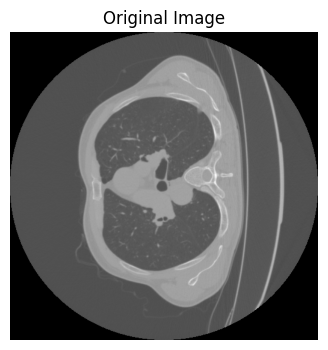

In [102]:
# 创建可视化
plt.figure(figsize=(4, 4))

# 原始图像
plt.imshow(image_data[:, :, slice_idx], cmap='gray')
plt.title('Original Image')
plt.axis('off')

## 掩码可视化

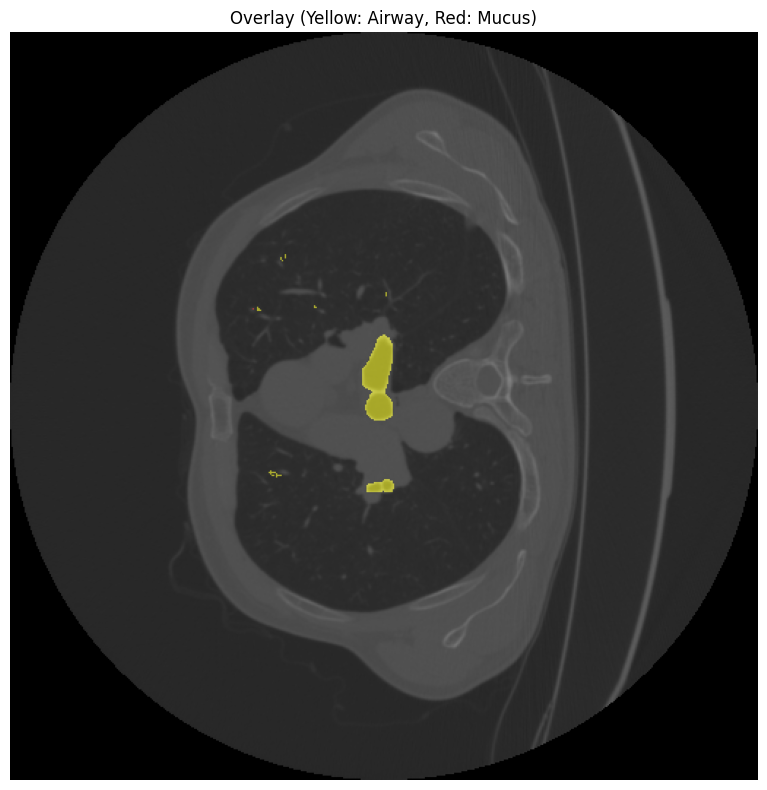

In [103]:
save_dir = '/workspace/Output_display/visualization_mask_results'
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(8, 8))
# 叠加图像
plt.imshow(image_data[:, :, slice_idx], cmap='gray')

# 创建颜色映射
mask_overlay = np.zeros((*image_data[:, :, slice_idx].shape, 3))
mask_overlay[combined_mask_data[:, :, slice_idx] == 1] = [1, 1, 0]  # 黄色 - 标签1
mask_overlay[combined_mask_data[:, :, slice_idx] == 2] = [1, 0, 0]  # 红色 - 标签2

plt.imshow(mask_overlay, alpha=0.5)
plt.title('Overlay (Yellow: Airway, Red: Mucus)')
plt.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f'{patient_id}_slice_{slice_idx}.png'), dpi=300)
plt.show()
